/home/emmdzzz/Tesis/Codigo/rotation-curve/.venv/lib/python3.13/site-packages/galpy/potential/SCFPotential.py:662: UserWarning: 'where' used without 'out', expect uninitialized memory in output. If this is intentional, use out=None.
  out = numpy.divide((r / a - 1.0), (r / a + 1.0), where=True ^ numpy.isinf(r))



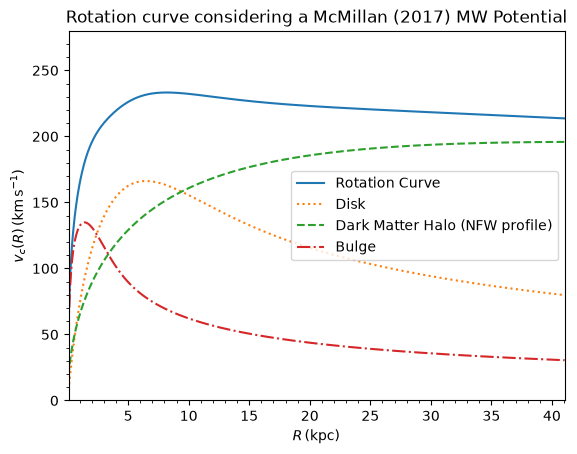

In [1]:
import galpy
from galpy.potential import plotRotcurve
from galpy.potential.mwpotentials import McMillan17 as mc17
import matplotlib.pyplot as plt

plotRotcurve(mc17, label = "Rotation Curve")
plotRotcurve(mc17[0], label = "Disk", overplot = True, linestyle = "dotted")
plotRotcurve(mc17[1], label = "Dark Matter Halo (NFW profile)", overplot = True, linestyle = "dashed")
plotRotcurve(mc17[2], label = "Bulge", overplot = True, linestyle = "dashdot")
plt.title("Rotation curve considering a McMillan (2017) MW Potential")
plt.legend()
plt.savefig("RotationCurve-McMillan2017-color.png")
plt.show()

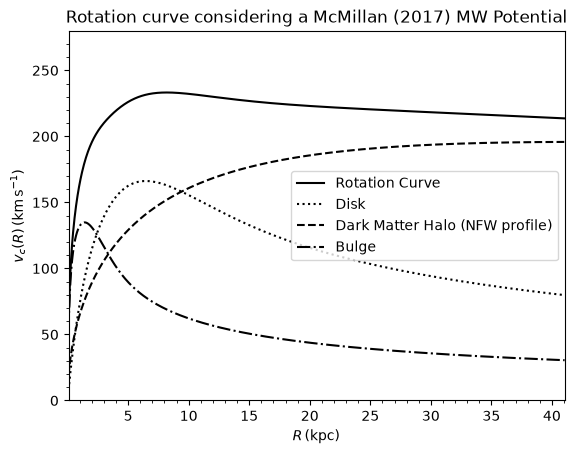

In [2]:
plotRotcurve(mc17, label = "Rotation Curve", color = "black")
plotRotcurve(mc17[0], label = "Disk", overplot = True, linestyle = "dotted", color = "black")
plotRotcurve(mc17[1], label = "Dark Matter Halo (NFW profile)", overplot = True, linestyle = "dashed", color = "black")
plotRotcurve(mc17[2], label = "Bulge", overplot = True, linestyle = "dashdot", color = "black")
plt.title("Rotation curve considering a McMillan (2017) MW Potential")
plt.legend()
plt.savefig("RotationCurve-McMillan2017.png")
plt.show()

In [ ]:
pip install astropy

In [4]:
import matplotlib.pyplot as plt
from astropy import units as u

from galpy.potential.mwpotentials import McMillan17 as mc17
from galpy.potential import (plotRotcurve, 
                             DoubleExponentialDiskPotential, 
                             DiskSCFPotential)
from galpy.util import conversion

# ---------------------------------------------------------
# 1. Extract Bulge and Halo from built-in McMillan17
# ---------------------------------------------------------
bulge = mc17[0]
halo = mc17[1]

# McMillan 2017 scaling parameters
ro = 8.21  # kpc
vo = 233.1 # km/s
sig_norm = conversion.surfdens_in_msolpc2(vo, ro)

# ---------------------------------------------------------
# 2. Recreate Stellar Disks
# ---------------------------------------------------------
thin_disk = DoubleExponentialDiskPotential(
    amp=896.0 * (u.Msun / u.pc**2), 
    hr=2.5 * u.kpc, 
    hz=0.3 * u.kpc, 
    ro=ro, vo=vo
)

thick_disk = DoubleExponentialDiskPotential(
    amp=183.0 * (u.Msun / u.pc**2), 
    hr=3.02 * u.kpc, 
    hz=0.9 * u.kpc, 
    ro=ro, vo=vo
)

# ---------------------------------------------------------
# 3. Recreate Gas Disks (with density holes)
# ---------------------------------------------------------
hi_disk = DiskSCFPotential(
    amp=1.0,
    Sigma={'type': 'exp', 'h': 7.0 / ro, 'Rhole': 4.0 / ro, 'amp': 53.1 / sig_norm},
    hz={'type': 'exp', 'h': 0.085 / ro},
    ro=ro, vo=vo
)

h2_disk = DiskSCFPotential(
    amp=1.0,
    Sigma={'type': 'exp', 'h': 1.5 / ro, 'Rhole': 12.0 / ro, 'amp': 2180.0 / sig_norm},
    hz={'type': 'exp', 'h': 0.045 / ro},
    ro=ro, vo=vo
)

# ---------------------------------------------------------
# 4. Plot Everything
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

# Plot the total potential using the built-in object
plotRotcurve(mc17, label="Total (McMillan 2017)", color='black', lw=2)

# Overplot all individual components
plotRotcurve(halo, overplot=True, label="Dark Matter Halo", ls='--')
plotRotcurve(bulge, overplot=True, label="Bulge", ls='--')
plotRotcurve(thin_disk, overplot=True, label="Thin Stellar Disk", ls='-.')
plotRotcurve(thick_disk, overplot=True, label="Thick Stellar Disk", ls='-.')
plotRotcurve(hi_disk, overplot=True, label="HI Gas Disk", ls=':')
plotRotcurve(h2_disk, overplot=True, label="H$_2$ Molecular Disk", ls=':')

# Formatting the graph
plt.title("McMillan 2017: Rotation Curve by Component")
plt.xlim(0, 30)   # Look at the first 30 kpc
plt.ylim(0, 300)  # Standard velocity range in km/s
plt.legend(loc='lower right', frameon=False)
plt.tight_layout()

# Save and show
plt.savefig("./McMillan17_Components.png", dpi=300)
plt.show()

RuntimeError: Input '2.5 kpc' not understood; should either be a number or an astropy Quantity